In [1]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import functools
print = functools.partial(print, flush=True)

In [2]:
DATA_DIR = '..'
DATA_FILES = [
    (1,  'ha-1sec-full-rl-v4.pqt'),
    (2,  'ha-2sec-full-rl-v4.pqt'),
    (3,  'ha-3sec-full-rl-v4.pqt'),
    (4,  'ha-4sec-full-rl-v4.pqt'),
    (8,  'ha-8sec-full-rl-v4.pqt'),
    (16, 'ha-16sec-full-rl-v4.pqt'),
]
OUT_DIR = 'e1_out'
REF_SECONDS = 2
EPS = 1e-9
W_SCALE = 64
MIN_PER = 8
N_BLOCKS = 10 
MATCH_SEEDS = 5
NUM_ROUNDS = 400
PARAMS = {
    'objective': 'regression_l1',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_data_in_leaf': 500,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'force_row_wise': True,
    'verbose': -1,
    'seed': 7,
}

NORM_COLS = ['jmaD1', 'jmaD2', 'haBody', 'haWickTop', 'haWickBott', 'dBody_3']
FEATURES = ['jmaD1', 'haColour', 'jmaD2', 'rsxLast', 'rsxLastD1', 'rsxLastD2',
            'cfbD1', 'haBody', 'candleCross', 'wickAsym', 'haWickTop', 'haWickBott',
            'bodyRange', 'dBody_3', 'dWickTopR_3', 'dWickBotR_3', 'g']

os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
def add_segments(df):
    date = df['date'].to_numpy()
    s = pd.Series(np.sign(df['jmaD1'].to_numpy())).replace(0.0, np.nan)
    s = s.groupby(date).ffill().groupby(date).bfill().to_numpy()
    m = len(df)
    new_day = np.empty(m, dtype=bool); new_day[0] = True
    new_day[1:] = date[1:] != date[:-1]
    flip = np.empty(m, dtype=bool); flip[0] = True
    flip[1:] = s[1:] != s[:-1]
    df['segId'] = np.cumsum(new_day | flip)
    df['g'] = df.groupby('segId').cumcount() + 1
    df['remaining'] = df.groupby('segId')['g'].transform('size') - df['g']

def prep(df, normalize):
    df = df.copy()
    df['candleCross'] = np.sign(df['Open'] - df['jma']).astype('int8')
    df['wickTop_body'] = df['haWickTop'] / (df['haBody'] + EPS)
    df['wickBot_body'] = df['haWickBott'] / (df['haBody'] + EPS)
    df['wickAsym'] = (df['haWickBott'] - df['haWickTop']) / (df['haBody'] + EPS)
    df['bodyRange'] = df['haBody'] / (df['haBody'] + df['haWickTop'] + df['haWickBott'] + EPS)
    gd = df.groupby(df['date'], sort=False)
    df['dBody_3'] = gd['haBody'].diff(3).fillna(0.0).values
    df['dWickTopR_3'] = gd['wickTop_body'].diff(3).fillna(0.0).values
    df['dWickBotR_3'] = gd['wickBot_body'].diff(3).fillna(0.0).values
    add_segments(df)
    if normalize:
        haRange = df['High'] - df['Low']
        scale = haRange.groupby(df['date'].to_numpy(), sort=False) \
                       .transform(lambda x: x.rolling(W_SCALE, min_periods=MIN_PER).mean())
        for c in NORM_COLS:
            df[c] = df[c] / scale
    return df

def load_shared():
    raw = {}
    for n, fname in DATA_FILES:
        raw[n] = pd.read_parquet(os.path.join(DATA_DIR, fname))
        raw[n]['date'] = raw[n]['timestamp'].dt.normalize()        
        print(f"loaded n={n}s rows={len(raw[n]):,} days={raw[n]['date'].nunique()}")
        
    ns = sorted(raw)
    shared = set.intersection(*(set(raw[n]['date'].unique()) for n in ns))
    dates = np.array(sorted(shared))
    print(f"shared days: {len(dates)}")
    for n in ns:
        f = raw[n]
        raw[n] = f[f['date'].isin(shared)].reset_index(drop=True)
    return raw, ns, dates

def add_block(df, block_starts):
    df['blk'] = (np.searchsorted(block_starts, df['date'].to_numpy(), side='right') - 1).astype('int8')

def baseline_mae(tr_g, tr_y, te_g, te_y):
    bl = pd.Series(tr_y).groupby(tr_g).mean()
    p = pd.Series(te_g).clip(upper=bl.index.max()).map(bl).to_numpy()
    return np.abs(te_y - p).mean()

def fit(X, y, params=None, rounds=None):
    return lgb.train(params or PARAMS, lgb.Dataset(X, y, free_raw_data=True),
                     num_boost_round=rounds or NUM_ROUNDS)

def frame_arrays(df):
    X = df[FEATURES].to_numpy(dtype=np.float32)
    y = df['remaining'].to_numpy(dtype=np.float32)
    g = df['g'].to_numpy()
    blk = df['blk'].to_numpy()
    return X, y, g, blk

def diagonal(df, label):
    X, y, g, blk = frame_arrays(df)
    out = []
    for f in range(N_BLOCKS - 1):
        tr = blk <= f
        te = blk == f + 1
        model = fit(X[tr], y[tr])
        mae = np.abs(y[te] - model.predict(X[te])).mean()
        mb = baseline_mae(g[tr], y[tr], g[te], y[te])
        out.append(1 - mae / mb)
        print(f"  {label} fold {f}: skill={out[-1]:.4f}  (mae={mae:.3f} base={mb:.3f})")
    out = np.array(out)
    print(f"  {label} mean skill = {out.mean():.4f} +- {out.std():.4f}")
    return out

In [41]:
print("=== G1: 2s diagonal, raw features ===")
n2, f2 = [x for x in DATA_FILES if x[0] == REF_SECONDS][0]
df2raw = pd.read_parquet(os.path.join(DATA_DIR, f2))
df2raw['date'] = df2raw['timestamp'].dt.normalize()
shared_probe = df2raw['date'].unique()
blocks = np.array_split(np.array(sorted(shared_probe)), N_BLOCKS)
starts = np.array([b[0] for b in blocks])
df2raw = prep(df2raw, normalize=False)
add_block(df2raw, starts)
g1 = diagonal(df2raw, "G1-raw")
del df2raw

frames, ns, dates = load_shared()
blocks = np.array_split(dates, N_BLOCKS)
starts = np.array([b[0] for b in blocks])
for n in ns:
    frames[n] = prep(frames[n], normalize=True)
    add_block(frames[n], starts)
    print(f"prepped n={n}s")

=== G1: 2s diagonal, raw features ===
  G1-raw fold 0: skill=0.1578  (mae=4.520 base=5.367)
  G1-raw fold 1: skill=0.1645  (mae=4.403 base=5.269)
  G1-raw fold 2: skill=0.1623  (mae=4.403 base=5.256)
  G1-raw fold 3: skill=0.1616  (mae=4.437 base=5.292)
  G1-raw fold 4: skill=0.1648  (mae=4.371 base=5.233)
  G1-raw fold 5: skill=0.1649  (mae=4.422 base=5.295)
  G1-raw fold 6: skill=0.1600  (mae=4.479 base=5.332)
  G1-raw fold 7: skill=0.1672  (mae=4.359 base=5.234)
  G1-raw fold 8: skill=0.1685  (mae=4.325 base=5.202)
  G1-raw mean skill = 0.1635 +- 0.0032
loaded n=1s rows=27,627,765 days=1158
loaded n=2s rows=14,256,735 days=1158
loaded n=3s rows=9,572,766 days=1158
loaded n=4s rows=7,193,919 days=1157
loaded n=8s rows=3,594,459 days=1155
loaded n=16s rows=1,788,654 days=1155
shared days: 1155
prepped n=1s
prepped n=2s
prepped n=3s
prepped n=4s
prepped n=8s
prepped n=16s


In [42]:
print("=== G2: 2s diagonal, normalized features ===")
g2 = diagonal(frames[REF_SECONDS], "G2-norm")
print(f"G1={g1.mean():.4f}  G2={g2.mean():.4f}  delta={(g2 - g1).mean():+.4f}")

arrs = {n: frame_arrays(frames[n]) for n in ns}
rpd = {n: frames[n].groupby('date').size() for n in ns}
F = N_BLOCKS - 1
k = len(ns)

base = np.zeros((F, k))
for j, n in enumerate(ns):
    X, y, g, blk = arrs[n]
    for f in range(F):
        base[f, j] = baseline_mae(g[blk <= f], y[blk <= f], g[blk == f + 1], y[blk == f + 1])

=== G2: 2s diagonal, normalized features ===
  G2-norm fold 0: skill=0.1595  (mae=4.510 base=5.367)
  G2-norm fold 1: skill=0.1663  (mae=4.392 base=5.268)
  G2-norm fold 2: skill=0.1640  (mae=4.394 base=5.256)
  G2-norm fold 3: skill=0.1630  (mae=4.429 base=5.291)
  G2-norm fold 4: skill=0.1664  (mae=4.364 base=5.235)
  G2-norm fold 5: skill=0.1662  (mae=4.415 base=5.295)
  G2-norm fold 6: skill=0.1613  (mae=4.472 base=5.332)
  G2-norm fold 7: skill=0.1683  (mae=4.355 base=5.237)
  G2-norm fold 8: skill=0.1701  (mae=4.316 base=5.200)
  G2-norm mean skill = 0.1650 +- 0.0032
G1=0.1635  G2=0.1650  delta=+0.0015


In [43]:
print("=== transfer matrix ===")
S = np.zeros((F, k, k))
for f in range(F):
    te = {n: (arrs[n][0][arrs[n][3] == f + 1], arrs[n][1][arrs[n][3] == f + 1]) for n in ns}
    for i, n1 in enumerate(ns):
        X, y, g, blk = arrs[n1]
        model = fit(X[blk <= f], y[blk <= f])
        for j, n2 in enumerate(ns):
            Xte, yte = te[n2]
            mae = np.abs(yte - model.predict(Xte)).mean()
            S[f, i, j] = 1 - mae / base[f, j]
        print(f"fold {f} train {n1:>2}s: " +
              " ".join(f"{n2}s={S[f, i, j]:.3f}" for j, n2 in enumerate(ns)))

Sm = S.mean(axis=0)
mat = pd.DataFrame(Sm, index=[f"tr{n}s" for n in ns], columns=[f"te{n}s" for n in ns])
R = pd.DataFrame(Sm / np.diag(Sm)[None, :], index=mat.index, columns=mat.columns)
print("\nmean skill matrix:\n", mat.round(4))
print("\ntransfer ratio R (col-normalized by target diagonal):\n", R.round(3))

=== transfer matrix ===
fold 0 train  1s: 1s=0.162 2s=0.160 3s=0.159 4s=0.161 8s=0.164 16s=0.164
fold 0 train  2s: 1s=0.162 2s=0.160 3s=0.159 4s=0.161 8s=0.165 16s=0.164
fold 0 train  3s: 1s=0.161 2s=0.159 3s=0.159 4s=0.161 8s=0.165 16s=0.164
fold 0 train  4s: 1s=0.160 2s=0.159 3s=0.158 4s=0.161 8s=0.165 16s=0.165
fold 0 train  8s: 1s=0.158 2s=0.157 3s=0.157 4s=0.159 8s=0.163 16s=0.163
fold 0 train 16s: 1s=0.155 2s=0.154 3s=0.154 4s=0.157 8s=0.161 16s=0.162
fold 1 train  1s: 1s=0.166 2s=0.166 3s=0.170 4s=0.172 8s=0.173 16s=0.171
fold 1 train  2s: 1s=0.165 2s=0.166 3s=0.170 4s=0.172 8s=0.174 16s=0.172
fold 1 train  3s: 1s=0.164 2s=0.166 3s=0.170 4s=0.172 8s=0.174 16s=0.173
fold 1 train  4s: 1s=0.164 2s=0.166 3s=0.170 4s=0.172 8s=0.174 16s=0.173
fold 1 train  8s: 1s=0.162 2s=0.165 3s=0.169 4s=0.172 8s=0.174 16s=0.172
fold 1 train 16s: 1s=0.159 2s=0.162 3s=0.167 4s=0.170 8s=0.172 16s=0.171
fold 2 train  1s: 1s=0.162 2s=0.164 3s=0.166 4s=0.166 8s=0.165 16s=0.167
fold 2 train  2s: 1s=0.162 

In [46]:
# ChatGPT proposed fix
print("=== row-matched diagonal ===")

nmax = max(ns)
diag_match = np.full((k, F, MATCH_SEEDS), np.nan)

block_codes = [
    np.asarray(b, dtype='datetime64[D]').astype(np.int64)
    for b in blocks
]

date_ranges = {}

for n in ns:
    d = frames[n]['date'].to_numpy(dtype='datetime64[D]').astype(np.int64)
    vals, starts, counts = np.unique(d, return_index=True, return_counts=True)

    date_ranges[n] = {
        v: (st, st + cnt)
        for v, st, cnt in zip(vals, starts, counts)
    }


def rows_for_dates(ranges, dates):
    parts = [
        np.arange(ranges[d][0], ranges[d][1])
        for d in dates
        if d in ranges
    ]

    return np.concatenate(parts) if parts else np.empty(0, dtype=np.int64)


for f in range(F):
    tr_dates_pd = np.concatenate(blocks[:f + 1])
    tr_dates = np.concatenate(block_codes[:f + 1])

    budget = int(rpd[nmax].loc[tr_dates_pd].sum())

    for i, n in enumerate(ns):
        X, y, g, blk = arrs[n]

        te = blk == f + 1
        Xte = X[te]
        yte = y[te]

        cnt = rpd[n].loc[tr_dates_pd].to_numpy()
        ranges = date_ranges[n]

        for s in range(MATCH_SEEDS):
            rng = np.random.default_rng(1000 * f + s)

            order = rng.permutation(len(tr_dates))
            cum = np.cumsum(cnt[order])

            take = np.searchsorted(cum, budget) + 1
            pick = tr_dates[order[:take]]

            idx = rows_for_dates(ranges, pick)

            model = fit(X[idx], y[idx])
            mae = np.abs(yte - model.predict(Xte)).mean()

            diag_match[i, f, s] = 1 - mae / base[f, i]

    print(f"fold {f} done")

=== row-matched diagonal ===
fold 0 done
fold 1 done
fold 2 done
fold 3 done
fold 4 done
fold 5 done
fold 6 done
fold 7 done
fold 8 done


In [47]:
dm = pd.DataFrame({
    'skill_full': np.diag(Sm),
    'skill_matched_mean': diag_match.mean(axis=(1, 2)),
    'skill_matched_std': diag_match.mean(axis=2).std(axis=1),
}, index=[f"{n}s" for n in ns])
print("\ndiagonal, full vs row-matched (train rows ~= 16s budget):\n", dm.round(4))


diagonal, full vs row-matched (train rows ~= 16s budget):
      skill_full  skill_matched_mean  skill_matched_std
1s       0.1630              0.1619             0.0030
2s       0.1650              0.1640             0.0039
3s       0.1664              0.1654             0.0049
4s       0.1670              0.1662             0.0047
8s       0.1666              0.1659             0.0062
16s      0.1650              0.1650             0.0053


In [49]:
train_idx = {
    (f, n): np.flatnonzero(arrs[n][3] <= f)
    for f in range(F)
    for n in ns
}

test_idx = {
    (f, n): np.flatnonzero(arrs[n][3] == f + 1)
    for f in range(F)
    for n in ns
}

## CHATGPT Version
print("=== pooled ===")

P = np.zeros((F, k, 3))

for f in range(F):
    Xtr_parts = []
    ytr_parts = []
    ncol_parts = []

    for n in ns:
        X, y, g, blk = arrs[n]

        idx = train_idx[(f, n)]

        Xtr_parts.append(X[idx])
        ytr_parts.append(y[idx])
        ncol_parts.append(np.full(len(idx), n, dtype=np.float32))

    Xtr = np.vstack(Xtr_parts)
    ytr = np.concatenate(ytr_parts)
    ncol = np.concatenate(ncol_parts)

    blind = fit(Xtr, ytr)

    Xtr_aware = np.empty((Xtr.shape[0], Xtr.shape[1] + 1), dtype=Xtr.dtype)
    Xtr_aware[:, :-1] = Xtr
    Xtr_aware[:, -1] = ncol

    aware = fit(Xtr_aware, ytr)

    del Xtr_parts, ytr_parts, ncol_parts
    del Xtr, Xtr_aware, ytr, ncol

    for j, n in enumerate(ns):
        X, y, g, blk = arrs[n]

        idx = test_idx[(f, n)]
        Xte = X[idx]
        yte = y[idx]

        P[f, j, 0] = S[f, j, j]

        mae = np.abs(yte - blind.predict(Xte)).mean()
        P[f, j, 1] = 1 - mae / base[f, j]

        Xte_aware = np.empty((Xte.shape[0], Xte.shape[1] + 1), dtype=Xte.dtype)
        Xte_aware[:, :-1] = Xte
        Xte_aware[:, -1] = n

        mae = np.abs(yte - aware.predict(Xte_aware)).mean()
        P[f, j, 2] = 1 - mae / base[f, j]

    print(f"fold {f} done")

=== pooled ===
fold 0 done
fold 1 done
fold 2 done
fold 3 done
fold 4 done
fold 5 done
fold 6 done
fold 7 done
fold 8 done



pooled comparison:
      per_frame  pooled_blind  pooled_aware
1s      0.1630        0.1630        0.1629
2s      0.1650        0.1650        0.1649
3s      0.1664        0.1662        0.1661
4s      0.1670        0.1667        0.1667
8s      0.1666        0.1660        0.1659
16s     0.1650        0.1641        0.1641


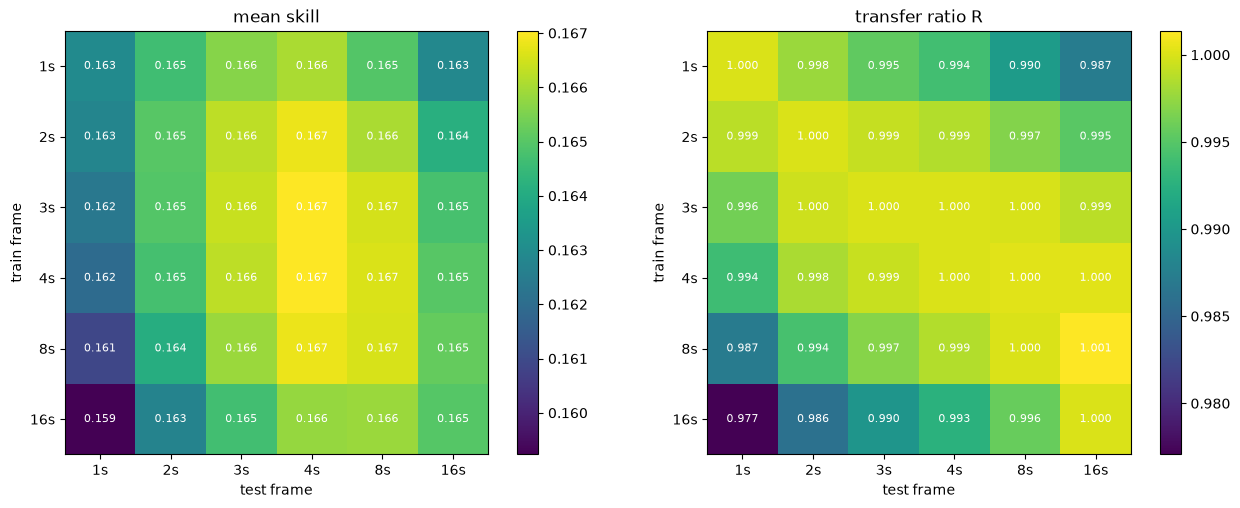

In [50]:
pooled = pd.DataFrame(P.mean(axis=0), index=[f"{n}s" for n in ns],
                      columns=['per_frame', 'pooled_blind', 'pooled_aware'])
print("\npooled comparison:\n", pooled.round(4))

long = pd.DataFrame([(f, n1, n2, S[f, i, j])
                     for f in range(F)
                     for i, n1 in enumerate(ns)
                     for j, n2 in enumerate(ns)],
                    columns=['fold', 'n_train', 'n_test', 'skill'])
long.to_csv(os.path.join(OUT_DIR, 'matrix_per_fold.csv'), index=False)
mat.to_csv(os.path.join(OUT_DIR, 'matrix_mean.csv'))
R.to_csv(os.path.join(OUT_DIR, 'R_matrix.csv'))
dm.to_csv(os.path.join(OUT_DIR, 'diag_matched.csv'))
pooled.to_csv(os.path.join(OUT_DIR, 'pooled.csv'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, M, title in ((axes[0], Sm, 'mean skill'), (axes[1], R.to_numpy(), 'transfer ratio R')):
    im = ax.imshow(M, cmap='viridis')
    ax.set_xticks(range(k), [f"{n}s" for n in ns])
    ax.set_yticks(range(k), [f"{n}s" for n in ns])
    ax.set_xlabel('test frame'); ax.set_ylabel('train frame'); ax.set_title(title)
    for a in range(k):
        for b in range(k):
            ax.text(b, a, f"{M[a, b]:.3f}", ha='center', va='center', color='w', fontsize=8)
    fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'matrix.png'), dpi=130)
plt.show()